In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_thr = pd.read_excel('../datasets/02_preprocessing.xlsx')
df_thr.info()
df_thr.head()

<class 'pandas.DataFrame'>
RangeIndex: 1810 entries, 0 to 1809
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   platform          1810 non-null   str  
 1   text              1810 non-null   str  
 2   cleaning          1802 non-null   str  
 3   case_folding      1802 non-null   str  
 4   normalisasi_kata  1800 non-null   str  
 5   tokenize          1810 non-null   str  
 6   stopword removal  1758 non-null   str  
 7   stemming          1758 non-null   str  
dtypes: str(8)
memory usage: 113.2 KB


,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih


## **Cleaning**

In [3]:
print('Jumlah missing value')
print(df_thr.isna().sum())

print('\nHANDLING MISSING VALUE\n')
df_thr.dropna(inplace=True)

print('Jumlah missing value')
print(df_thr.isna().sum())

Jumlah missing value
platform             0
text                 0
cleaning             8
case_folding         8
normalisasi_kata    10
tokenize             0
stopword removal    52
stemming            52
dtype: int64

HANDLING MISSING VALUE

Jumlah missing value
platform            0
text                0
cleaning            0
case_folding        0
normalisasi_kata    0
tokenize            0
stopword removal    0
stemming            0
dtype: int64


# **3. LABELING**

## **3.1 Laxicon Method Based 2 Class**

In [4]:
# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        sentiment = "Negatif" if sentiment_score <= 0 else "Positif"
        return sentiment_score, sentiment
    return 0, "Negatif"

df_thr[['score', 'sentiment']] = df_thr['normalisasi_kata'].apply(lambda x: pd.Series(determine_sentiment(x)))
df_thr.head(20)

,platform,text,cleaning,case_folding,normalisasi_kata,tokenize,stopword removal,stemming,score,sentiment
0,tiktok,asa te boga walikota..hanya KDM yg ku punya,asa te boga walikotahanya KDM yg ku punya,asa te boga walikotahanya kdm yg ku punya,"asa henteu boga wali kota, hanya kdm yang ku p...","['asa', 'henteu', 'boga', 'wali', 'kota,', 'ha...","asa henteu boga wali kota, kdm ku",asa henteu boga wali kota kdm ku,-1,Negatif
1,tiktok,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,sedih gara gara bapak ini,"['sedih', 'gara', 'gara', 'bapak', 'ini']",sedih gara gara,sedih gara gara,-3,Negatif
2,tiktok,"hade goreng ku basa, ieu mah Pareum we eweuh k...",hade goreng ku basa ieu mah Pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,"['hade', 'goreng', 'ku', 'basa', 'ieu', 'mah',...",hade goreng ku basa ieu mah pareum we eweuh kl...,hade goreng ku basa ieu mah pareum we eweuh kl...,-2,Negatif
3,tiktok,Ciamis ts cair Minggu kmari .Tasik mah kmha ce...,Ciamis ts cair Minggu kmari Tasik mah kmha cer...,ciamis ts cair minggu kmari tasik mah kmha cer...,ciamis atos cair minggu kamari tasikmalaya mah...,"['ciamis', 'atos', 'cair', 'minggu', 'kamari',...",ciamis atos cair minggu kamari tasikmalaya mah...,ciamis atos cair minggu kamar tasikmalaya mah ...,0,Negatif
4,tiktok,nyesel milih dia,nyesel milih dia,nyesel milih dia,menyesal memilih dia,"['menyesal', 'memilih', 'dia']",menyesal memilih,sesal pilih,-1,Negatif
5,tiktok,terlalu maksakeun jadi walikota,terlalu maksakeun jadi walikota,terlalu maksakeun jadi walikota,terlalu maksakeun jadi wali kota,"['terlalu', 'maksakeun', 'jadi', 'wali', 'kota']",maksakeun wali kota,maksakeun wali kota,-2,Negatif
6,tiktok,ke1,ke1,ke1,ke1,['ke1'],ke1,ke1,0,Negatif
7,tiktok,asa kkara tahun ieu walikota ku Viman jadi kieu,asa kkara tahun ieu walikota ku Viman jadi kieu,asa kkara tahun ieu walikota ku viman jadi kieu,asa kakara tahun ieu wali kota ku viman jadi kieu,"['asa', 'kakara', 'tahun', 'ieu', 'wali', 'kot...",asa kakara ieu wali kota ku viman kieu,asa kakara ieu wali kota ku viman kieu,-1,Negatif
8,tiktok,2,2,2,2,['2'],2,2,0,Negatif
9,tiktok,Parahhh,Parahhh,parahhh,parahhh,['parahhh'],parahhh,parahhh,0,Negatif


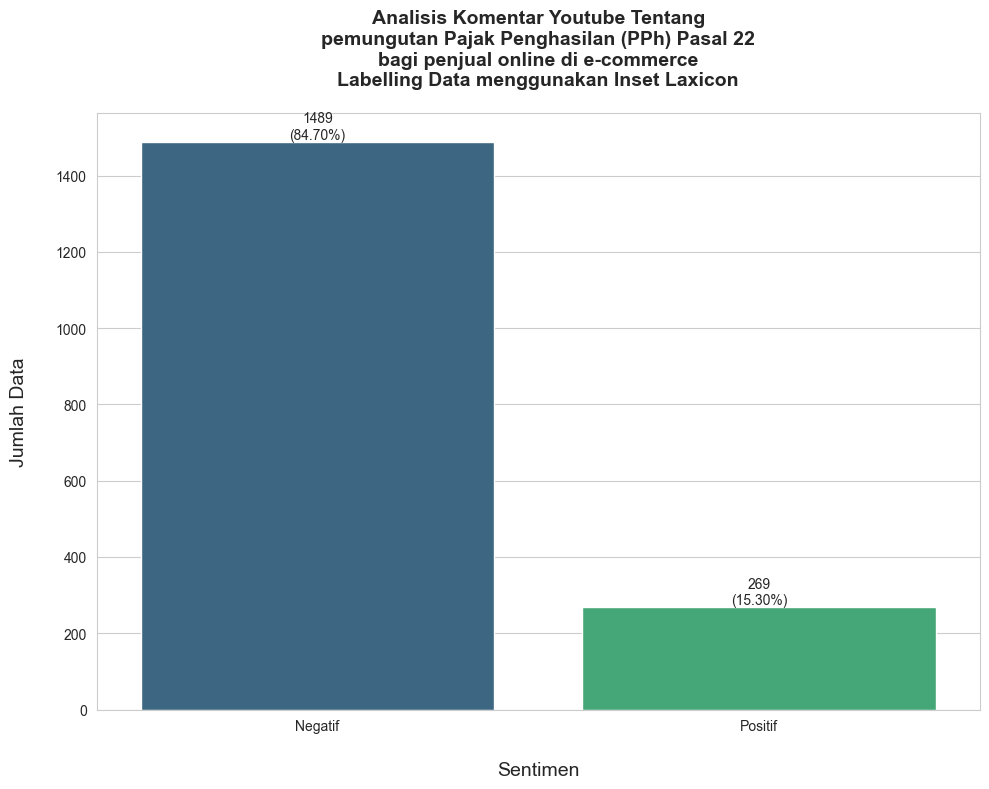

In [5]:
import warnings
warnings.filterwarnings("ignore")

sentiment_count = df_thr['sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(10, 8))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='viridis')
plt.title('Analisis Komentar Youtube Tentang\npemungutan Pajak Penghasilan (PPh) Pasal 22\nbagi penjual online di e-commerce\nLabelling Data menggunakan Inset Laxicon', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Sentimen', fontsize=14, labelpad=20)
plt.ylabel('Jumlah Data', fontsize=14, labelpad=20)

total = len(df_thr['sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../img/03 Distribusi Data Sentimen.png')
plt.show()

In [6]:
df_thr.to_excel('../datasets/03_labeling.xlsx', index=False)